# EDA Plots — Calgary PM2.5 (2020–2023)
This notebook generates four PNG plots using only matplotlib:
Trend, Seasonal Boxplot, Scatter (vs Temp), and Correlation Heatmap.


In [17]:
csv_url = "https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Final%20Project/Data/Final_Cleaned_Data/Calgary_PM25_Weather_Cleaned_v3.csv"
df = pd.read_csv(csv_url, parse_dates=['date'])


In [18]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to the cleaned PM2.5 + weather dataset (CSV file)
csv_path = 'Calgary_PM25_Weather_Cleaned_v3.csv'

# Read the CSV file, parse the 'date' column as datetime,
# sort the rows by date, and reset the index for clean ordering
df = pd.read_csv(csv_path, parse_dates=['date']).sort_values('date').reset_index(drop=True)

# Print the shape of the loaded dataset (rows, columns)
print('Loaded shape:', df.shape)

# Display the first few rows to verify correct loading
df.head()


Loaded shape: (1461, 13)


,date,PM25,Mean Temp (°C)_x,Total Precip (mm)_x,PM25_lag1,PM25_roll3,month,dow,season,Mean Temp (°C)_y,Total Precip (mm)_y,year,dayofyear
0,2020-01-01,5.080895,-1.6,0.0,NaN,NaN,1,2,Winter,-1.6,0.0,2020,1
1,2020-01-02,4.965239,-4.2,1.4,5.080895,NaN,1,3,Winter,-4.2,1.4,2020,2
2,2020-01-03,6.367912,-0.4,0.0,4.965239,5.471348,1,4,Winter,-0.4,0.0,2020,3
3,2020-01-04,4.359544,2.4,0.6,6.367912,5.230898,1,5,Winter,2.4,0.6,2020,4
4,2020-01-05,3.706763,-4.1,0.1,4.359544,4.811406,1,6,Winter,-4.1,0.1,2020,5


## Trend — Daily PM2.5 (2020–2023)

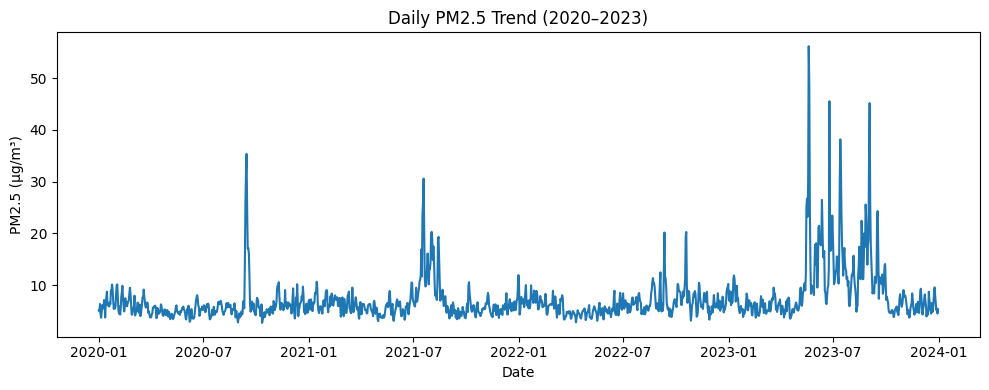

In [19]:
# Create a figure with size 10x4
plt.figure(figsize=(10,4))

# Plot PM2.5 values over time
plt.plot(df['date'], df['PM25'])

# Add title and axis labels
plt.title('Daily PM2.5 Trend (2020–2023)')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')

# Improve spacing
plt.tight_layout()

# Display the plot directly below the cell
plt.show()


## Seasonal Boxplot — PM2.5 by Season

/tmp/ipython-input-879625418.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_season, labels=season_order, showfliers=True)


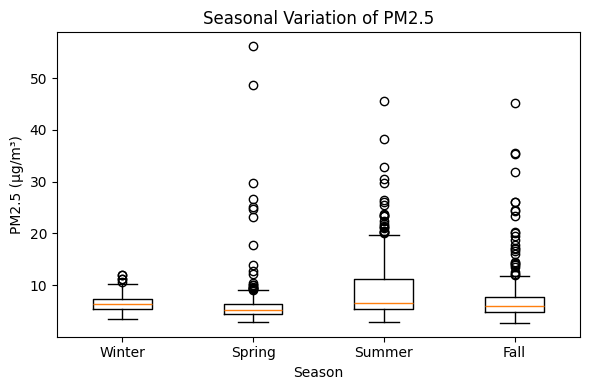

In [20]:
# Define the order of seasons
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Create a list of PM2.5 values for each season (dropping missing values)
data_by_season = [
    df.loc[df['season'] == s, 'PM25'].dropna().values
    for s in season_order
]

# Create the figure
plt.figure(figsize=(6,4))

# Draw the boxplot for seasonal PM2.5 variation
plt.boxplot(data_by_season, labels=season_order, showfliers=True)

# Add title and axis labels
plt.title('Seasonal Variation of PM2.5')
plt.xlabel('Season')
plt.ylabel('PM2.5 (µg/m³)')

# Adjust spacing so labels and plot fit cleanly
plt.tight_layout()

# Display the plot directly below the cell
plt.show()


## Scatter — PM2.5 vs Mean Temperature (°C)

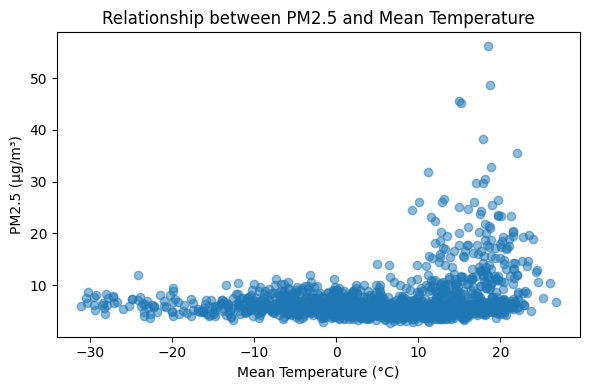

In [21]:
# Scatter plot: PM2.5 vs Mean Temperature

plt.figure(figsize=(6,4))

# Use the existing temperature column ('Mean Temp (°C)_x')
plt.scatter(df['Mean Temp (°C)_x'], df['PM25'], alpha=0.5)

# Add title and labels
plt.title('Relationship between PM2.5 and Mean Temperature')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('PM2.5 (µg/m³)')

# Improve layout
plt.tight_layout()

# Display the plot directly under the cell
plt.show()


## Heatmap — Correlation Matrix of Variables

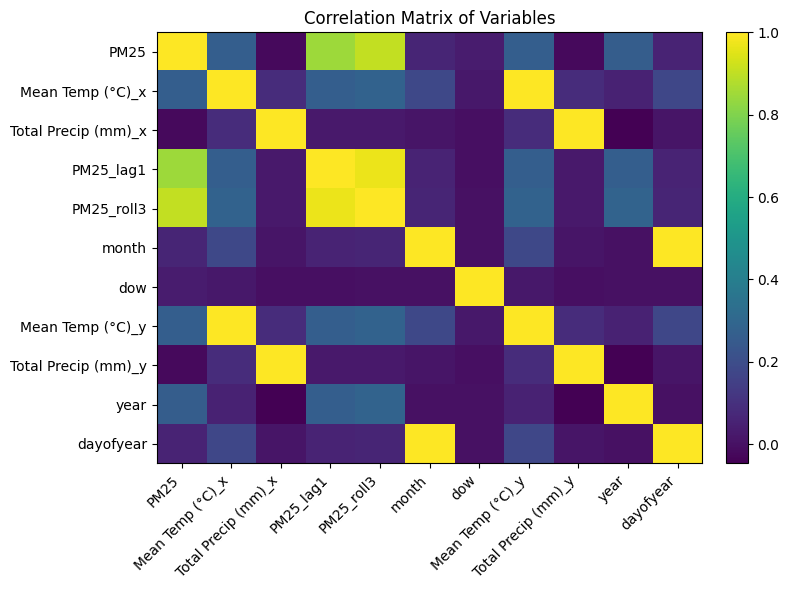

In [22]:
# Select only numeric columns for correlation calculation
num_df = df.select_dtypes(include=['number']).copy()

# Compute the correlation matrix for numerical variables
corr = num_df.corr()

# Create a figure for the heatmap
plt.figure(figsize=(8,6))

# Display the correlation matrix as a heatmap
im = plt.imshow(corr, aspect='auto')

# Add a colorbar showing correlation strength scale
plt.colorbar(im, fraction=0.046, pad=0.04)

# Set x-axis tick labels as column names
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')

# Set y-axis tick labels as column names
plt.yticks(range(len(corr.columns)), corr.columns)

# Add plot title
plt.title('Correlation Matrix of Variables')

# Adjust layout so labels don't overlap
plt.tight_layout()

# Show the heatmap directly under this cell
plt.show()


### Done ✓  Four PNG files saved in the working directory.